# Quantum Optimization of East African Remittance Corridors — Exploratory Data Analysis

**Challenge A** — multi-objective provider selection and routing across East Africa's mobile
money corridors.

**Data:** World Bank *Remittance Prices Worldwide* (RPW), 2011 Q1 – 2025 Q3, filtered to
East African source countries.

### What this notebook is for

The decision problem is: *for a given corridor, which firm/service should be selected, and
under what weighting of fee, FX spread and speed?* Before we can write a QUBO or run QAOA we
need to know, from the data itself:

1. Are the three objectives **actually in conflict?** (If they are not, the multi-objective
   machinery is unnecessary and a single sort would do.)
2. **How big is the prize?** The problem statement claims 15–30 % excess cost. Is that right?
3. **How large is the feasible set** per decision? This sets the qubit count.
4. **What does the corridor graph look like?** Is multi-hop routing even possible?
5. Which fields are **trustworthy enough** to be objective coefficients?

Every section ends with a `>>> TAKEAWAY` line stating what it implies for the model.

In [1]:
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# --- Chart design tokens -------------------------------------------------------
# Validated categorical palette, assigned in fixed order (never cycled). Scatter /
# all-pairs forms use only the first three slots, which clear colour-vision-deficiency
# separation on every pair; bar and line forms may use more.
C = {
    "blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
    "magenta": "#e87ba4", "green": "#008300", "violet": "#4a3aa7", "red": "#e34948",
}
SERIES = [C["blue"], C["orange"], C["aqua"], C["yellow"], C["magenta"], C["green"],
          C["violet"], C["red"]]
SAFE3 = [C["blue"], C["orange"], C["aqua"]]        # for scatter / small multiples
INK, INK2, INK3 = "#0b0b0b", "#52514e", "#8a8985"  # text tokens: never a series colour
SURFACE, GRID = "#fcfcfb", "#e6e5e1"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "font.size": 10,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.7, "axes.axisbelow": True,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 10, "legend.frameon": False, "lines.linewidth": 2,
})

def style(ax, title=None, sub=None, xlab=None, ylab=None, xgrid=False):
    """Recessive axes; one grid direction only; subtitle carries the units."""
    if title:
        ax.set_title(title, color=INK, pad=24 if sub else 10)
    if sub:
        ax.text(0, 1.015, sub, transform=ax.transAxes, color=INK3, fontsize=9, va="bottom")
    ax.set_xlabel(xlab or "", fontsize=9)
    ax.set_ylabel(ylab or "", fontsize=9)
    ax.grid(axis="x" if xgrid else "y")
    ax.grid(axis="y" if xgrid else "x", visible=False)
    return ax

DATA = Path("../Data/rpw_dataset_2011_2025_q3_EastAfrica.csv")
raw = pd.read_csv(DATA)
print(f"{raw.shape[0]:,} rows x {raw.shape[1]} columns")

4,504 rows x 39 columns


## 1. What a row means

RPW is a **price survey**, not a transaction log. One row = *one firm's advertised offer on
one corridor in one quarter*, priced at two fixed send amounts:

| Prefix | Send amount | Meaning |
|---|---|---|
| `cc1 …` | **USD 200** equivalent | the small-remittance benchmark |
| `cc2 …` | **USD 500** equivalent | the larger benchmark |

The three objective columns map directly onto the challenge's three objectives:

| Challenge objective | RPW column | Units |
|---|---|---|
| transaction fee | `cc1 total cost %` − `cc1 fx margin` | % of principal |
| FX spread | `cc1 fx margin` | % over the interbank mid |
| settlement time | `speed actual` | ordinal band |

`total cost %` is the **sum** of the fee and the FX margin — so the fee component has to be
derived by subtraction, and fee and FX must never both be added to total cost in an
objective function (that would double-count).

In [2]:
schema = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "nulls": raw.isna().sum(),
    "null_%": (raw.isna().mean() * 100).round(1),
    "nunique": raw.nunique(),
})
schema["role"] = "descriptive"
schema.loc[["cc1 total cost %", "cc2 total cost %", "cc1 fx margin", "cc2 fx margin",
            "speed actual"], "role"] = ">>> OBJECTIVE"
schema.loc[["corridor", "source_name", "destination_name"], "role"] = ">>> GRAPH EDGE"
schema.loc[["firm", "firm_type"], "role"] = ">>> DECISION VARIABLE"
schema.loc[["period", "date"], "role"] = ">>> TIME INDEX"
schema.sort_values("role", ascending=False)

,dtype,nulls,null_%,nunique,role
id,int64,0,0.0,4504,descriptive
access point,str,0,0.0,17,descriptive
pickup method,str,231,5.1,11,descriptive
receiving network coverage,str,0,0.0,6,descriptive
transparent,str,0,0.0,3,descriptive
inter lcu bank fx,float64,0,0.0,638,descriptive
cc2 lcu fx rate,float64,4,0.1,1420,descriptive
cc2 lcu fee,float64,4,0.1,352,descriptive
cc2 lcu code,str,0,0.0,3,descriptive
cc2 denomination amount,float64,0,0.0,1,descriptive


## 2. Data quality — what has to be cleaned before it can be a coefficient

Four issues materially affect the optimisation, and one is a genuine finding rather than a
defect.

In [3]:
print("--- 2a. The same firm appears under several spellings -------------------")
for pat in ["KCB", "Kenya Commercial", "NBC", "National Bank of Commerce", "Exim",
            "CRDB", "Cooperative Rural", "BPR", "Charter", "Ecobank", "EcoBank", "MTN"]:
    hits = sorted(raw.loc[raw.firm.str.contains(pat, case=False, na=False), "firm"].unique())
    if len(hits) > 1:
        print(f"  {pat:<22} -> {hits}")

print("\n--- 2b. Free-text categoricals differ only by casing --------------------")
for col in ["transparent", "pickup method"]:
    v = raw[col].dropna()
    collapsed = v.str.lower().str.strip().nunique()
    print(f"  {col:<16} {v.nunique()} raw levels -> {collapsed} after case-folding")

print("\n--- 2c. Missingness ----------------------------------------------------")
print(raw.isna().sum()[lambda s: s > 0].to_string())

print("\n--- 2d. Negative FX margins (NOT an error) -----------------------------")
neg = raw[raw["cc1 fx margin"] < 0]
print(f"  {len(neg)} rows ({len(neg)/len(raw):.1%}) quote a rate BETTER than the interbank mid.")
print(f"  Range {neg['cc1 fx margin'].min():.2f}% to {neg['cc1 fx margin'].max():.2f}%.")
print("  These are promotional / loss-leading rates. They are real and must be kept:")
print("  clipping them at zero would delete exactly the offers the optimiser should find.")
print(neg.groupby("firm_type").size().to_string())

--- 2a. The same firm appears under several spellings -------------------
  KCB                    -> ['KCB (Kenya Commercial Bank)', 'KCB Bank', 'Kenya Commercial Bank (KCB)']
  Kenya Commercial       -> ['KCB (Kenya Commercial Bank)', 'Kenya Commercial Bank (KCB)']
  NBC                    -> ['NBC (National Bank of Commerce Ltd)', 'National Bank of Commerce Ltd (NBC)']
  National Bank of Commerce -> ['NBC (National Bank of Commerce Ltd)', 'National Bank of Commerce Ltd (NBC)']
  Exim                   -> ['Exim Bank', 'Exim Bank Tanzania Ltd']
  CRDB                   -> ['CRDB Bank', 'Cooperative Rural Development Bank (CRDB)']
  BPR                    -> ['BPR Bank Rwanda PLC', 'BPR Bank Rwanda Plc']
  Charter                -> ['Standard Charterd Bank Tanzania', 'Standard Chartered Bank']
  Ecobank                -> ['EcoBank Rapid Transfer', 'Ecobank', 'Ecobank RapidCash', 'Ecobank Rapidcash']
  EcoBank                -> ['EcoBank Rapid Transfer', 'Ecobank', 'Ecobank RapidCash',

In [4]:
# ---- Clean layer --------------------------------------------------------------
FIRM_MAP = {
    "Kenya Commercial Bank (KCB)": "KCB", "KCB Bank": "KCB", "KCB (Kenya Commercial Bank)": "KCB",
    "National Bank of Commerce Ltd (NBC)": "NBC", "NBC (National Bank of Commerce Ltd)": "NBC",
    "Exim Bank Tanzania Ltd": "Exim Bank",
    "Cooperative Rural Development Bank (CRDB)": "CRDB Bank",
    "BPR Bank Rwanda PLC": "BPR Bank Rwanda", "BPR Bank Rwanda Plc": "BPR Bank Rwanda",
    "Standard Charterd Bank Tanzania": "Standard Chartered Bank",
    "Ecobank Rapidcash": "Ecobank RapidCash", "MTN": "MTN Mobile Money",
}
# Ordinal speed -> hours. Midpoints of each advertised band; the ordering is what
# matters to the optimiser, the absolute values only set the normalisation scale.
SPEED_HOURS = {"Less than one hour": 0.5, "Same day": 12, "Next day": 24,
               "2 days": 48, "3-5 days": 96}

df = raw.copy()
df["firm"] = df["firm"].replace(FIRM_MAP)
df["transparent"] = df["transparent"].str.lower()
df["pickup method"] = df["pickup method"].str.lower().str.strip()
df["year"] = df["period"].str[:4].astype(int)
df["quarter"] = df["period"].str[-2:]
df["t"] = df["year"] + (df["period"].str[5].astype(int) - 1) / 4
df["src"], df["dst"] = df["corridor"].str[:3], df["corridor"].str[3:]
df["hours"] = df["speed actual"].map(SPEED_HOURS)

# The three objectives, at both send amounts
for cc in ("cc1", "cc2"):
    df[f"{cc} fee %"] = df[f"{cc} total cost %"] - df[f"{cc} fx margin"]

print(f"firms: {raw.firm.nunique()} raw -> {df.firm.nunique()} after de-duplication")
print(f"corridors: {df.corridor.nunique()}   quarters: {df.period.nunique()}   "
      f"{df.t.min():.2f} to {df.t.max():.2f}")
print("\n>>> TAKEAWAY: 9 duplicate firm identities would have been modelled as distinct")
print(">>> decision variables. Negative FX margins are signal, not noise — never clip them.")

firms: 47 raw -> 38 after de-duplication
corridors: 8   quarters: 54   2011.00 to 2025.50

>>> TAKEAWAY: 9 duplicate firm identities would have been modelled as distinct
>>> decision variables. Negative FX margins are signal, not noise — never clip them.


## 3. Coverage — how many choices does a sender actually have?

The size of the feasible set per decision is what sizes the quantum circuit: one binary
variable per candidate offer.

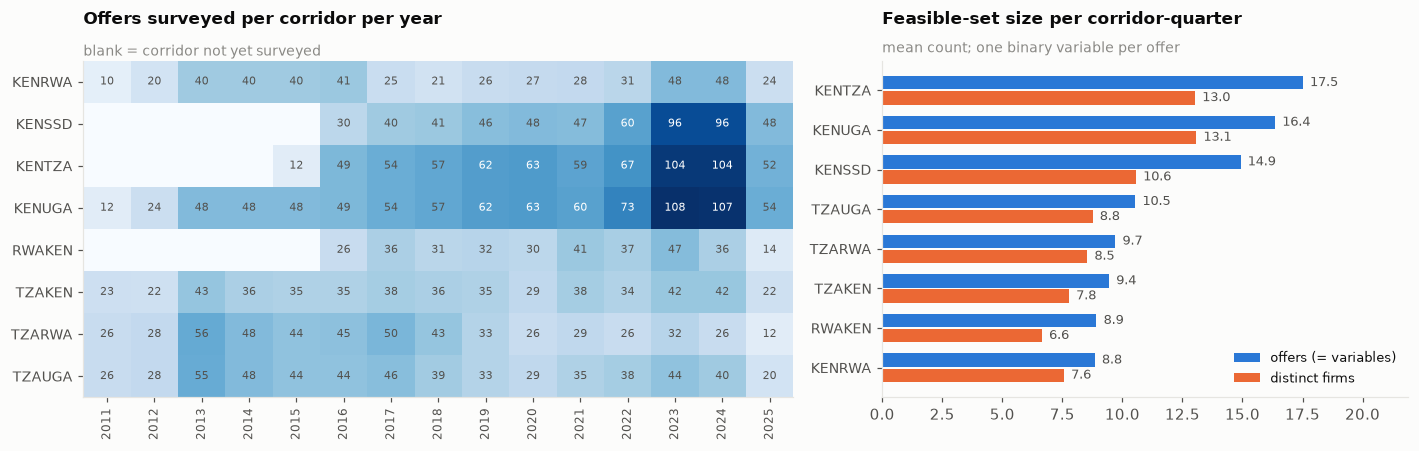

offers per corridor-quarter : min 4, mean 11.8, max 30
firms  per corridor-quarter : min 4, mean 9.4, max 17

>>> TAKEAWAY: a sender chooses among 4–30 offers (mean 12) from 9 firms.
>>> That is a 30-variable one-hot QUBO at worst — small enough that
>>> exhaustive enumeration gives exact ground truth to benchmark QAOA against.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.35, 1]})

# Left: corridor x year coverage as a sequential heatmap (one hue, light -> dark)
mat = pd.crosstab(df.corridor, df.year)
im = axes[0].imshow(mat.values, aspect="auto", cmap="Blues", vmin=0)
axes[0].set_xticks(range(len(mat.columns)), mat.columns, rotation=90, fontsize=8)
axes[0].set_yticks(range(len(mat.index)), mat.index, fontsize=9)
axes[0].grid(False)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.values[i, j]
        if v:
            axes[0].text(j, i, v, ha="center", va="center", fontsize=7,
                         color="#ffffff" if v > mat.values.max() * 0.55 else INK2)
axes[0].set_title("Offers surveyed per corridor per year", color=INK, loc="left", pad=24)
axes[0].text(0, 1.015, "blank = corridor not yet surveyed",
             transform=axes[0].transAxes, color=INK3, fontsize=9)

# Right: the feasible set. A firm can list several products (agent, online, branch),
# so the number of OFFERS a sender chooses between exceeds the number of firms — and it
# is offers, not firms, that become binary decision variables.
cq = df.groupby(["corridor", "period"]).agg(firms=("firm", "nunique"), offers=("id", "size"))
agg = cq.groupby(level=0).mean().sort_values("offers")
yy = np.arange(len(agg))
axes[1].barh(yy + 0.19, agg.offers, height=0.34, color=C["blue"], label="offers (= variables)")
axes[1].barh(yy - 0.19, agg.firms, height=0.34, color=C["orange"], label="distinct firms")
for i, (o, f) in enumerate(zip(agg.offers, agg.firms)):
    axes[1].text(o + 0.3, i + 0.19, f"{o:.1f}", va="center", fontsize=8.5, color=INK2)
    axes[1].text(f + 0.3, i - 0.19, f"{f:.1f}", va="center", fontsize=8.5, color=INK2)
axes[1].set_yticks(yy, agg.index, fontsize=9)
axes[1].set_xlim(0, agg.offers.max() * 1.25)
axes[1].legend(fontsize=8.5, loc="lower right")
style(axes[1], "Feasible-set size per corridor-quarter",
      "mean count; one binary variable per offer", xgrid=True)
plt.tight_layout()
plt.show()

print(f"offers per corridor-quarter : min {cq.offers.min()}, mean {cq.offers.mean():.1f}, "
      f"max {cq.offers.max()}")
print(f"firms  per corridor-quarter : min {cq.firms.min()}, mean {cq.firms.mean():.1f}, "
      f"max {cq.firms.max()}")
print(f"\n>>> TAKEAWAY: a sender chooses among {cq.offers.min()}–{cq.offers.max()} offers "
      f"(mean {cq.offers.mean():.0f}) from {cq.firms.mean():.0f} firms.")
print(f">>> That is a {cq.offers.max()}-variable one-hot QUBO at worst — small enough that")
print(">>> exhaustive enumeration gives exact ground truth to benchmark QAOA against.")

## 4. The three objectives, one at a time

Cost is heavily right-skewed: the median offer costs ~11 % of a USD 200 transfer, but the
tail runs past 90 %.

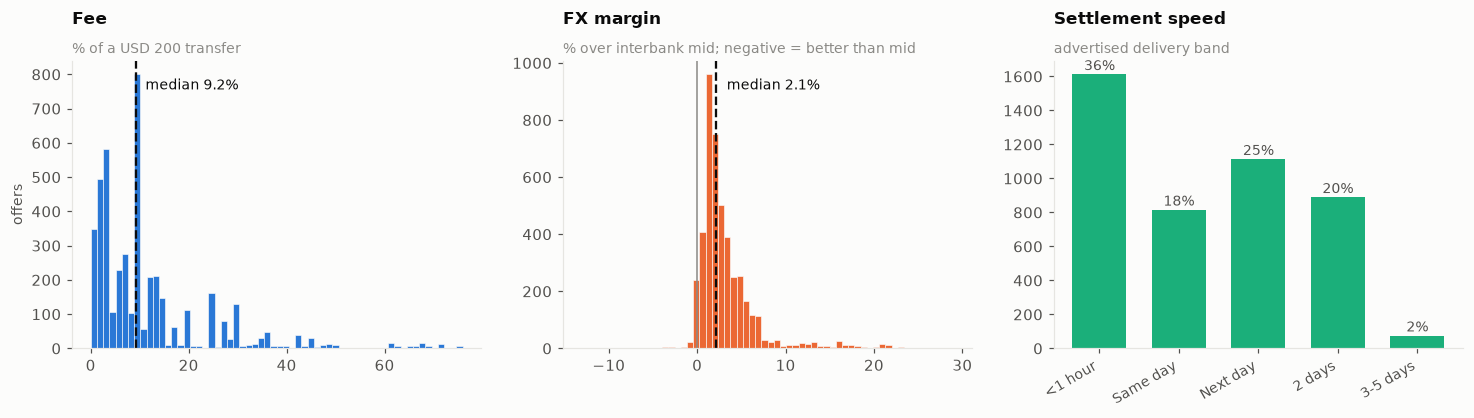

       cc1 fee %  cc1 fx margin  cc1 total cost %  cc2 total cost %
count    4504.00        4504.00           4504.00           4500.00
mean       11.94           3.22             15.16              8.72
std        12.74           3.64             14.59              7.20
min         0.00         -13.08             -9.00             -8.72
5%          0.71           0.05              2.98              2.57
25%         3.00           1.25              6.47              5.03
50%         9.17           2.15             10.88              6.76
75%        13.63           4.04             17.03              9.73
95%        35.95           9.71             45.65             22.36
max        75.94          29.00             97.89             52.80


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))

axes[0].hist(df["cc1 fee %"], bins=60, color=C["blue"], edgecolor=SURFACE, linewidth=0.4)
axes[0].axvline(df["cc1 fee %"].median(), color=INK, lw=1.5, ls="--")
axes[0].text(df["cc1 fee %"].median() + 2, axes[0].get_ylim()[1] * 0.9,
             f"median {df['cc1 fee %'].median():.1f}%", color=INK, fontsize=9)
style(axes[0], "Fee", "% of a USD 200 transfer", ylab="offers")

axes[1].hist(df["cc1 fx margin"], bins=60, color=C["orange"], edgecolor=SURFACE, linewidth=0.4)
axes[1].axvline(0, color=INK3, lw=1)
axes[1].axvline(df["cc1 fx margin"].median(), color=INK, lw=1.5, ls="--")
axes[1].text(df["cc1 fx margin"].median() + 1.2, axes[1].get_ylim()[1] * 0.9,
             f"median {df['cc1 fx margin'].median():.1f}%", color=INK, fontsize=9)
style(axes[1], "FX margin", "% over interbank mid; negative = better than mid")

sp = df["speed actual"].value_counts().reindex(list(SPEED_HOURS))
axes[2].bar(range(len(sp)), sp.values, color=C["aqua"], width=0.68)
axes[2].set_xticks(range(len(sp)), [s.replace("Less than one hour", "<1 hour") for s in sp.index],
                   rotation=30, ha="right", fontsize=9)
for i, v in enumerate(sp.values):
    axes[2].text(i, v + 25, f"{v/len(df):.0%}", ha="center", fontsize=9, color=INK2)
style(axes[2], "Settlement speed", "advertised delivery band")
plt.tight_layout()
plt.show()

print(df[["cc1 fee %", "cc1 fx margin", "cc1 total cost %", "cc2 total cost %"]]
      .describe(percentiles=[.05, .25, .5, .75, .95]).round(2).to_string())

## 5. Insight 1 — the FX spread is a *fifth* of the bill and only weakly tracks the fee

This is the load-bearing result for the whole formulation. If fee and FX margin were tightly
correlated, one number would summarise cost and there would be no trade-off to optimise.

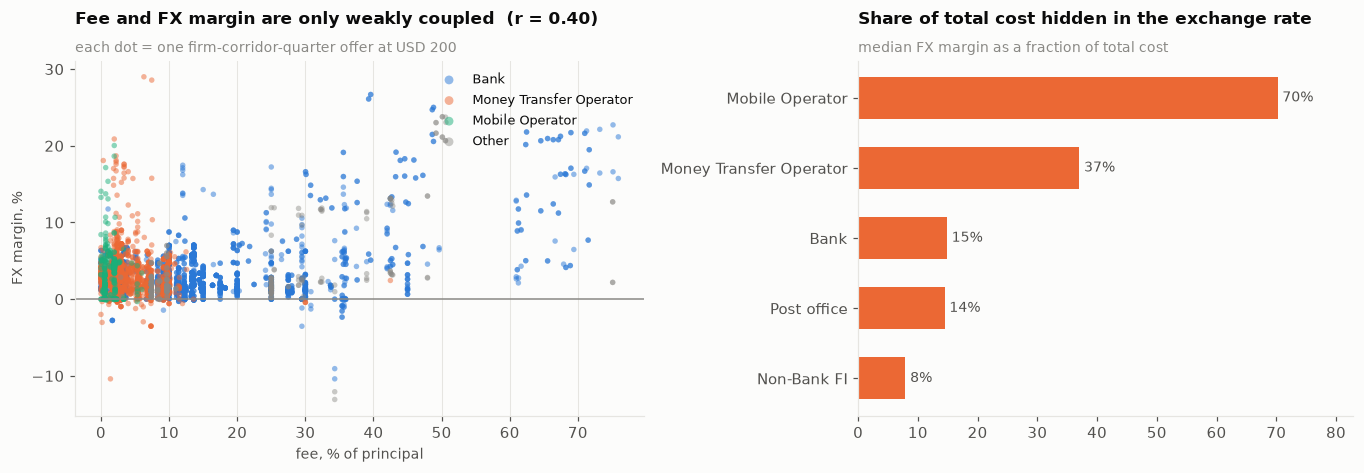

>>> TAKEAWAY: FX margin is 21% of the median bill yet correlates only
>>> r=0.40 with the fee — a genuinely 2-dimensional cost objective. A router that
>>> optimises the advertised fee alone is blind to a fifth of what the sender pays,
>>> and to the axis on which providers differ most.


In [7]:
sub = df.dropna(subset=["cc1 fee %", "cc1 fx margin"])
r = np.corrcoef(sub["cc1 fee %"], sub["cc1 fx margin"])[0, 1]
fx_share = (df["cc1 fx margin"] / df["cc1 total cost %"].replace(0, np.nan)).median()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4), gridspec_kw={"width_ratios": [1.15, 1]})

# Left: fee vs FX scatter, coloured by firm type (3 safe slots + Other)
top3 = ["Bank", "Money Transfer Operator", "Mobile Operator"]
for name, col in zip(top3, SAFE3):
    s = sub[sub.firm_type == name]
    axes[0].scatter(s["cc1 fee %"], s["cc1 fx margin"], s=13, alpha=0.5, color=col,
                    edgecolor="none", label=name)
s = sub[~sub.firm_type.isin(top3)]
axes[0].scatter(s["cc1 fee %"], s["cc1 fx margin"], s=13, alpha=0.45, color=INK3,
                edgecolor="none", label="Other")
axes[0].axhline(0, color=INK3, lw=1)
axes[0].legend(fontsize=8.5, loc="upper right", markerscale=1.6)
style(axes[0], f"Fee and FX margin are only weakly coupled  (r = {r:.2f})",
      "each dot = one firm-corridor-quarter offer at USD 200",
      xlab="fee, % of principal", ylab="FX margin, %")
axes[0].grid(axis="x")

# Right: what share of the total bill is hidden in the exchange rate
by_t = (df.groupby("firm_type")
          .apply(lambda g: (g["cc1 fx margin"] / g["cc1 total cost %"].replace(0, np.nan)).median())
          .sort_values())
axes[1].barh(by_t.index, by_t.values * 100, color=C["orange"], height=0.6)
for k, v in by_t.items():
    axes[1].text(v * 100 + 0.8, k, f"{v:.0%}", va="center", fontsize=9, color=INK2)
axes[1].set_xlim(0, by_t.max() * 118)
style(axes[1], "Share of total cost hidden in the exchange rate",
      "median FX margin as a fraction of total cost", xgrid=True)
plt.tight_layout()
plt.show()

print(f">>> TAKEAWAY: FX margin is {fx_share:.0%} of the median bill yet correlates only")
print(f">>> r={r:.2f} with the fee — a genuinely 2-dimensional cost objective. A router that")
print(">>> optimises the advertised fee alone is blind to a fifth of what the sender pays,")
print(">>> and to the axis on which providers differ most.")

## 6. Insight 2 — speed is **not** a competing objective in this market

The challenge brief assumes fee, FX spread and settlement time all pull against each other.
The data says otherwise for the speed axis: in East Africa the *fastest* channels are also
the *cheapest*, because they are digital (mobile money and MTO agent networks), while the
slow channels are correspondent-bank wires carrying flat SWIFT-style fees.

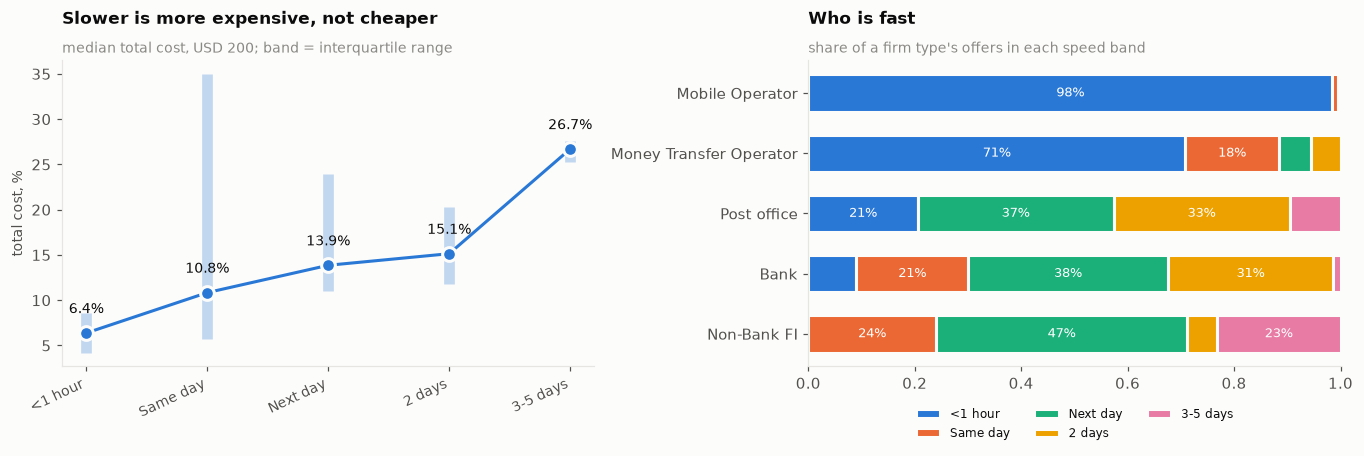

Spearman rank correlation of settlement hours with each cost component:
cc1 total cost %    0.578
cc1 fee %           0.611
cc1 fx margin      -0.078

>>> TAKEAWAY: cost and speed are POSITIVELY correlated (slower costs more), so a
>>> naive 3-objective Pareto search wastes effort on a dominated region. Speed still
>>> belongs in the model — but as a CONSTRAINT (deliver within T hours) rather than
>>> a competing objective. The real trade-off surface is fee vs FX margin.


In [8]:
order = [k for k in SPEED_HOURS]
g = df.groupby("speed actual")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))

med = g["cc1 total cost %"].median().reindex(order)
q1 = g["cc1 total cost %"].quantile(.25).reindex(order)
q3 = g["cc1 total cost %"].quantile(.75).reindex(order)
x = np.arange(len(order))
axes[0].vlines(x, q1, q3, color=C["blue"], lw=7, alpha=0.28)
axes[0].plot(x, med, "o-", color=C["blue"], ms=9, markeredgecolor=SURFACE, markeredgewidth=2)
for i, v in enumerate(med):
    axes[0].text(i, v + 2.2, f"{v:.1f}%", ha="center", fontsize=9, color=INK)
axes[0].set_xticks(x, [s.replace("Less than one hour", "<1 hour") for s in order],
                   rotation=25, ha="right", fontsize=9)
style(axes[0], "Slower is more expensive, not cheaper",
      "median total cost, USD 200; band = interquartile range", ylab="total cost, %")

# Speed mix by firm type — stacked, with a 2px surface gap between segments
mix = pd.crosstab(df.firm_type, df["speed actual"], normalize="index").reindex(columns=order)
mix = mix.loc[mix[order[0]].sort_values().index]
left = np.zeros(len(mix))
for col, colr in zip(order, SERIES):
    axes[1].barh(mix.index, mix[col], left=left, color=colr, height=0.62,
                 edgecolor=SURFACE, linewidth=2,
                 label=col.replace("Less than one hour", "<1 hour"))
    for i, (l, w) in enumerate(zip(left, mix[col])):
        if w > 0.14:
            axes[1].text(l + w / 2, i, f"{w:.0%}", ha="center", va="center",
                         fontsize=8.5, color="#ffffff")
    left += mix[col].values
axes[1].set_xlim(0, 1)
axes[1].legend(fontsize=8, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.10))
style(axes[1], "Who is fast", "share of a firm type's offers in each speed band", xgrid=True)
axes[1].grid(False)
plt.tight_layout()
plt.show()

sp_corr = df[["hours", "cc1 total cost %", "cc1 fee %", "cc1 fx margin"]].corr(
    method="spearman")["hours"].drop("hours")
print("Spearman rank correlation of settlement hours with each cost component:")
print(sp_corr.round(3).to_string())
print("\n>>> TAKEAWAY: cost and speed are POSITIVELY correlated (slower costs more), so a")
print(">>> naive 3-objective Pareto search wastes effort on a dominated region. Speed still")
print(">>> belongs in the model — but as a CONSTRAINT (deliver within T hours) rather than")
print(">>> a competing objective. The real trade-off surface is fee vs FX margin.")

## 7. Insight 3 — the prize is provider **selection**, and it is far bigger than 15–30 %

For every corridor-quarter, compare the cheapest available offer with the median offer a
sender might plausibly walk into. The gap is the value an optimiser can capture *without any
new infrastructure* — just by choosing correctly among offers that already exist.

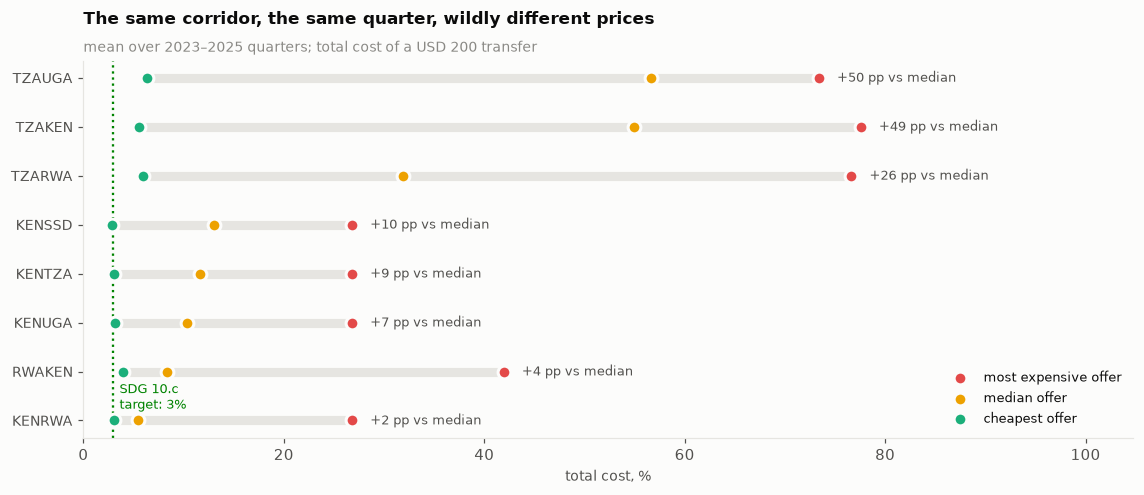

Mean saving, cheapest vs median offer :  19.78 pp
Mean saving, cheapest vs worst  offer :  42.85 pp
Median relative overpayment at the median offer : 4.2x the best available price

>>> TAKEAWAY: choosing the cheapest existing offer instead of a typical one saves
>>> ~20 PERCENTAGE POINTS of the principal on average — several times the
>>> 15–30% relative figure in the brief. The optimisation problem is real and the
>>> objective coefficients are wide enough that near-optimal beats status quo easily.


In [9]:
recent = df[df.year >= 2023]
g = recent.groupby(["corridor", "period"])["cc1 total cost %"]
disp = pd.DataFrame({"best": g.min(), "median": g.median(), "worst": g.max(), "n": g.size()})
disp = disp[disp.n >= 3]
disp["gap_vs_median"] = disp["median"] - disp["best"]
disp["gap_vs_worst"] = disp["worst"] - disp["best"]
by_corr = disp.groupby(level=0)[["best", "median", "worst", "gap_vs_median"]].mean()
by_corr = by_corr.sort_values("gap_vs_median")

fig, ax = plt.subplots(figsize=(10.5, 4.6))
y = np.arange(len(by_corr))
ax.hlines(y, by_corr.best, by_corr.worst, color=GRID, lw=6)
ax.scatter(by_corr.worst, y, s=70, color=C["red"], zorder=3, label="most expensive offer",
           edgecolor=SURFACE, linewidth=2)
ax.scatter(by_corr["median"], y, s=70, color=C["yellow"], zorder=3, label="median offer",
           edgecolor=SURFACE, linewidth=2)
ax.scatter(by_corr.best, y, s=70, color=C["aqua"], zorder=3, label="cheapest offer",
           edgecolor=SURFACE, linewidth=2)
for i, (k, row) in enumerate(by_corr.iterrows()):
    ax.text(row.worst + 1.8, i, f"+{row.gap_vs_median:.0f} pp vs median",
            va="center", fontsize=8.5, color=INK2)
ax.set_yticks(y, by_corr.index, fontsize=9)
ax.axvline(3, color=C["green"], lw=1.5, ls=":")
ax.text(3.6, 0.15, "SDG 10.c\ntarget: 3%", color=C["green"], fontsize=8.5, va="bottom")
ax.set_xlim(0, by_corr.worst.max() * 1.35)
ax.legend(fontsize=8.5, loc="lower right")
style(ax, "The same corridor, the same quarter, wildly different prices",
      "mean over 2023–2025 quarters; total cost of a USD 200 transfer",
      xlab="total cost, %", xgrid=True)
plt.tight_layout()
plt.show()

print(f"Mean saving, cheapest vs median offer : {disp.gap_vs_median.mean():6.2f} pp")
print(f"Mean saving, cheapest vs worst  offer : {disp.gap_vs_worst.mean():6.2f} pp")
print(f"Median relative overpayment at the median offer : "
      f"{(disp['median'] / disp['best']).median():.1f}x the best available price")
print("\n>>> TAKEAWAY: choosing the cheapest existing offer instead of a typical one saves")
print(f">>> ~{disp.gap_vs_median.mean():.0f} PERCENTAGE POINTS of the principal on average — several times the")
print(">>> 15–30% relative figure in the brief. The optimisation problem is real and the")
print(">>> objective coefficients are wide enough that near-optimal beats status quo easily.")

## 8. Insight 4 — the dispersion is structural: banks vs. digital channels

The spread in §7 is not random noise around a price. It is a **bimodal market**: correspondent
banks charging flat fees that crush a USD 200 transfer, sitting alongside digital channels an
order of magnitude cheaper. TZAKEN and TZAUGA — where the median offer costs >50 % — are
corridors whose surveyed sample is dominated by Tanzanian bank wires.

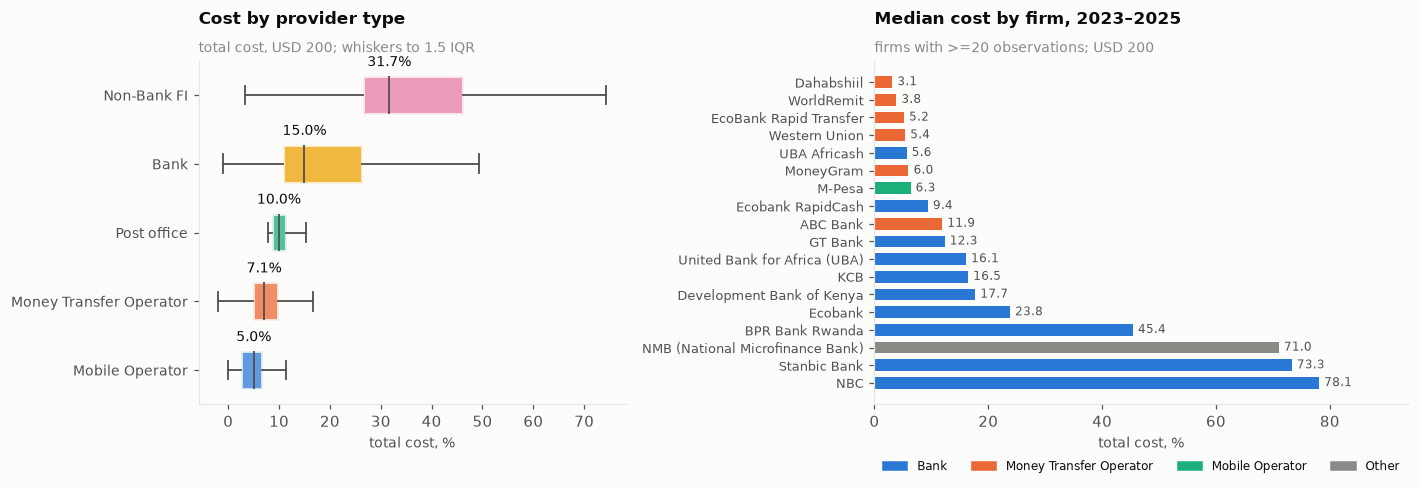

>>> TAKEAWAY: firm_type is a strong prior on cost, but it is NOT a substitute for the
>>> per-offer numbers — ABC Bank is typed 'Money Transfer Operator', UBA Africash is
>>> typed 'Bank'. Use firm_type for interpretation and for corridor-availability
>>> constraints; use the measured fee/FX/speed triple as the objective coefficients.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1, 1.25]})

ft_order = df.groupby("firm_type")["cc1 total cost %"].median().sort_values().index
data = [df.loc[df.firm_type == t, "cc1 total cost %"].dropna() for t in ft_order]
bp = axes[0].boxplot(data, vert=False, patch_artist=True, widths=0.55, showfliers=False)
for patch, colr in zip(bp["boxes"], SERIES):
    patch.set(facecolor=colr, alpha=0.75, edgecolor=SURFACE, linewidth=2)
for el in ("medians", "whiskers", "caps"):
    for it in bp[el]:
        it.set(color=INK2, linewidth=1.2)
axes[0].set_yticks(range(1, len(ft_order) + 1), ft_order, fontsize=9)
for i, t in enumerate(ft_order):
    m = df.loc[df.firm_type == t, "cc1 total cost %"].median()
    axes[0].text(m, i + 1.42, f"{m:.1f}%", ha="center", fontsize=9, color=INK)
style(axes[0], "Cost by provider type", "total cost, USD 200; whiskers to 1.5 IQR",
      xlab="total cost, %", xgrid=True)

top = (recent.groupby("firm")
       .agg(cost=("cc1 total cost %", "median"), n=("id", "size"),
            ftype=("firm_type", lambda s: s.mode()[0]))
       .query("n >= 20").sort_values("cost"))
colmap = {t: c for t, c in zip(top3, SAFE3)}
cols = [colmap.get(t, INK3) for t in top.ftype]
axes[1].barh(range(len(top)), top.cost, color=cols, height=0.66)
axes[1].set_yticks(range(len(top)), top.index, fontsize=8.5)
axes[1].invert_yaxis()
for i, v in enumerate(top.cost):
    axes[1].text(v + 0.9, i, f"{v:.1f}", va="center", fontsize=8, color=INK2)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in SAFE3 + [INK3]]
axes[1].legend(handles, top3 + ["Other"], fontsize=8, ncol=4,
               loc="upper center", bbox_to_anchor=(0.5, -0.13))
axes[1].set_xlim(0, top.cost.max() * 1.2)
style(axes[1], "Median cost by firm, 2023–2025",
      "firms with >=20 observations; USD 200", xlab="total cost, %", xgrid=True)
plt.tight_layout()
plt.show()

print(">>> TAKEAWAY: firm_type is a strong prior on cost, but it is NOT a substitute for the")
print(">>> per-offer numbers — ABC Bank is typed 'Money Transfer Operator', UBA Africash is")
print(">>> typed 'Bank'. Use firm_type for interpretation and for corridor-availability")
print(">>> constraints; use the measured fee/FX/speed triple as the objective coefficients.")

## 9. Insight 5 — only ~29 % of offers are Pareto-optimal

Computing the non-dominated set over (fee %, FX margin, settlement hours) tells us how much
of the search space is worth exploring — and how many binary variables a QUBO really needs.

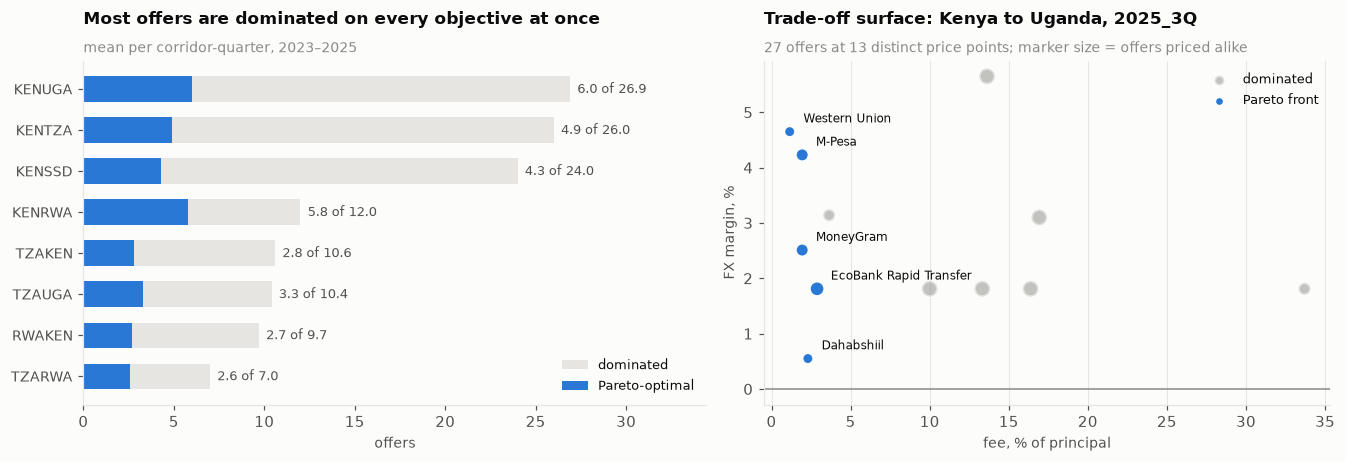

Across 80 corridor-quarters: 15.8 offers -> 4.0 Pareto-optimal (29%)
Largest feasible set observed: 27 offers, 14 on the front

>>> TAKEAWAY: 29% of offers are non-dominated, so ~71% of the
>>> search space can be pruned classically before any quantum step. A one-hot QUBO over
>>> the full set needs up to 27 qubits per corridor; over the pruned front, ~14.
>>> Both are comfortably inside NISQ range, and brute force gives exact ground truth
>>> to benchmark QAOA against.


In [11]:
def pareto_mask(v):
    """Rows not dominated on any of the (minimised) objective columns."""
    n = len(v)
    keep = np.ones(n, bool)
    for i in range(n):
        for j in range(n):
            if i != j and np.all(v[j] <= v[i]) and np.any(v[j] < v[i]):
                keep[i] = False
                break
    return keep

OBJ = ["cc1 fee %", "cc1 fx margin", "hours"]
rows = []
for (c, p), s in recent.groupby(["corridor", "period"]):
    s = s.dropna(subset=OBJ)
    if len(s) < 3:
        continue
    k = pareto_mask(s[OBJ].values)
    rows.append({"corridor": c, "period": p, "offers": len(s), "pareto": int(k.sum())})
pf = pd.DataFrame(rows)
pf["frac"] = pf.pareto / pf.offers
by_c = pf.groupby("corridor")[["offers", "pareto", "frac"]].mean().sort_values("offers")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3), gridspec_kw={"width_ratios": [1.1, 1]})

y = np.arange(len(by_c))
axes[0].barh(y, by_c.offers, color=GRID, height=0.62, label="dominated")
axes[0].barh(y, by_c.pareto, color=C["blue"], height=0.62, label="Pareto-optimal")
for i, (o, p) in enumerate(zip(by_c.offers, by_c.pareto)):
    axes[0].text(o + 0.4, i, f"{p:.1f} of {o:.1f}", va="center", fontsize=8.5, color=INK2)
axes[0].set_yticks(y, by_c.index, fontsize=9)
axes[0].set_xlim(0, by_c.offers.max() * 1.28)
axes[0].legend(fontsize=8.5, loc="lower right")
style(axes[0], "Most offers are dominated on every objective at once",
      "mean per corridor-quarter, 2023–2025", xlab="offers", xgrid=True)

# The trade-off surface for one representative corridor-quarter
ex = recent[recent.corridor == "KENUGA"]
cq = ex[ex.period == ex.period.max()].dropna(subset=OBJ)
k = pareto_mask(cq[OBJ].values)
cq = cq.assign(front=k)
# Several products from one firm can price identically; size the marker by multiplicity
# so overlapping offers stay visible.
pts = (cq.groupby(["cc1 fee %", "cc1 fx margin", "front"])
         .agg(mult=("id", "size"), firms=("firm", lambda x: ", ".join(sorted(set(x)))))
         .reset_index())
dom, fr = pts[~pts.front], pts[pts.front]
axes[1].scatter(dom["cc1 fee %"], dom["cc1 fx margin"], s=40 + 22 * dom.mult, color=INK3,
                alpha=0.5, edgecolor=SURFACE, linewidth=2, label="dominated")
axes[1].scatter(fr["cc1 fee %"], fr["cc1 fx margin"], s=40 + 22 * fr.mult, color=C["blue"],
                edgecolor=SURFACE, linewidth=2, zorder=3, label="Pareto front")
for _, rw in fr.iterrows():
    axes[1].annotate(rw.firms, (rw["cc1 fee %"], rw["cc1 fx margin"]),
                     textcoords="offset points", xytext=(9, 6), fontsize=8, color=INK)
axes[1].axhline(0, color=INK3, lw=1)
axes[1].legend(fontsize=8.5, loc="upper right", markerscale=0.7)
style(axes[1], f"Trade-off surface: Kenya to Uganda, {cq.period.iloc[0]}",
      f"{len(cq)} offers at {len(pts)} distinct price points; marker size = offers priced alike",
      xlab="fee, % of principal", ylab="FX margin, %")
axes[1].grid(axis="x")
plt.tight_layout()
plt.show()

print(f"Across {len(pf)} corridor-quarters: {pf.offers.mean():.1f} offers -> "
      f"{pf.pareto.mean():.1f} Pareto-optimal ({pf.frac.mean():.0%})")
print(f"Largest feasible set observed: {pf.offers.max()} offers, "
      f"{pf.pareto.max()} on the front")
print(f"\n>>> TAKEAWAY: {pf.frac.mean():.0%} of offers are non-dominated, so ~{1-pf.frac.mean():.0%} of the")
print(">>> search space can be pruned classically before any quantum step. A one-hot QUBO over")
print(f">>> the full set needs up to {pf.offers.max()} qubits per corridor; over the pruned front, ~{pf.pareto.max()}.")
print(">>> Both are comfortably inside NISQ range, and brute force gives exact ground truth")
print(">>> to benchmark QAOA against.")

## 10. Insight 6 — the corridor graph is sparse, and that is the routing opportunity

The brief's optional extension — "generalized to a multi-corridor portfolio/routing problem
if the same funds could go via an indirect country pair" — turns out to be the *more*
interesting problem, because most country pairs have **no direct priced corridor at all**.

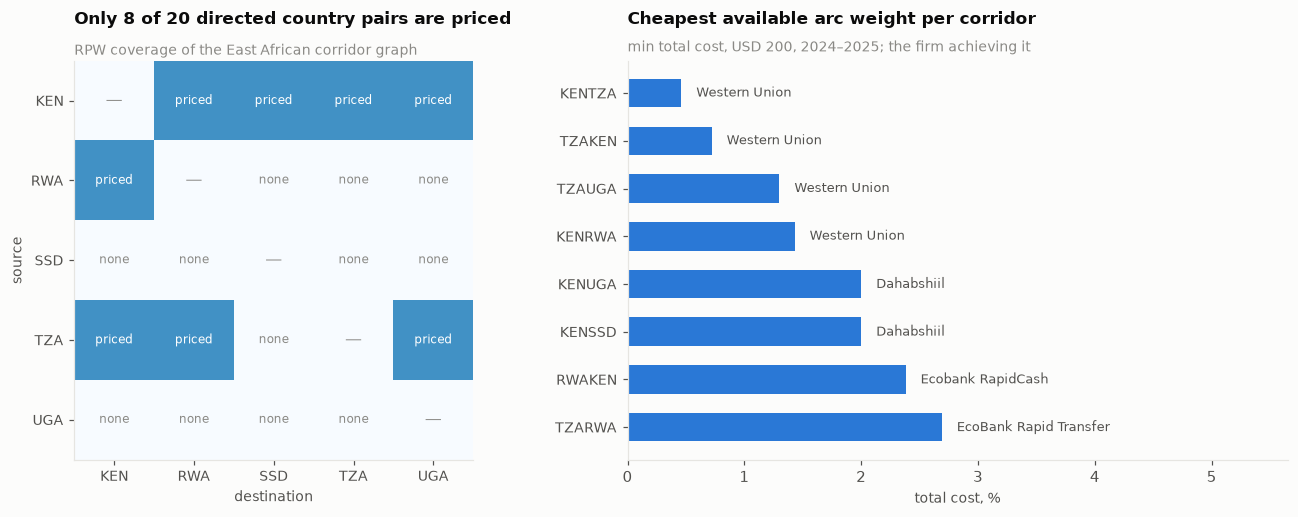

nodes: ['KEN', 'RWA', 'SSD', 'TZA', 'UGA']
priced directed corridors (8): ['KENRWA', 'KENSSD', 'KENTZA', 'KENUGA', 'RWAKEN', 'TZAKEN', 'TZARWA', 'TZAUGA']

UNPRICED pairs (12 of 20): ['RWASSD', 'RWATZA', 'RWAUGA', 'SSDKEN', 'SSDRWA', 'SSDTZA', 'SSDUGA', 'TZASSD', 'UGAKEN', 'UGARWA', 'UGASSD', 'UGATZA']

Out-degree (can money be SENT from here?):
KEN    4
RWA    1
SSD    0
TZA    3
UGA    0

>>> Uganda and South Sudan are pure SINKS — RPW prices money going in, never out.


In [12]:
NODES = sorted(set(df.src) | set(df.dst))
EDGES = sorted(df.corridor.unique())
present = set(EDGES)
allpairs = [(a, b) for a in NODES for b in NODES if a != b]
missing = [a + b for a, b in allpairs if a + b not in present]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), gridspec_kw={"width_ratios": [1, 1.15]})

# Adjacency matrix: which directed pairs are priced at all
adj = pd.DataFrame(0, index=NODES, columns=NODES)
for e in EDGES:
    adj.loc[e[:3], e[3:]] = 1
axes[0].imshow(adj.values, cmap="Blues", vmin=0, vmax=1.6)
axes[0].set_xticks(range(len(NODES)), NODES, fontsize=9)
axes[0].set_yticks(range(len(NODES)), NODES, fontsize=9)
axes[0].set_xlabel("destination", fontsize=9)
axes[0].set_ylabel("source", fontsize=9)
axes[0].grid(False)
for i, a in enumerate(NODES):
    for j, b in enumerate(NODES):
        if a == b:
            axes[0].text(j, i, "—", ha="center", va="center", color=INK3, fontsize=11)
        else:
            axes[0].text(j, i, "priced" if adj.loc[a, b] else "none", ha="center", va="center",
                         fontsize=8, color="#ffffff" if adj.loc[a, b] else INK3)
axes[0].set_title("Only 8 of 20 directed country pairs are priced", color=INK, loc="left", pad=24)
axes[0].text(0, 1.015, "RPW coverage of the East African corridor graph",
             transform=axes[0].transAxes, color=INK3, fontsize=9)

# Best cost per priced edge — the arc weights the optimiser would use
latest = df[df.year >= 2024]
edge_best = (latest.loc[latest.groupby("corridor")["cc1 total cost %"].idxmin()]
             .set_index("corridor")[["firm", "cc1 total cost %", "cc1 fx margin", "hours"]]
             .sort_values("cc1 total cost %"))
yy = np.arange(len(edge_best))
axes[1].barh(yy, edge_best["cc1 total cost %"], color=C["blue"], height=0.6)
axes[1].set_yticks(yy, edge_best.index, fontsize=9)
axes[1].invert_yaxis()
for i, (k, rw) in enumerate(edge_best.iterrows()):
    axes[1].text(rw["cc1 total cost %"] + 0.06, i, f"  {rw.firm}", va="center",
                 fontsize=8.5, color=INK2)
axes[1].set_xlim(0, edge_best["cc1 total cost %"].max() * 2.1)
style(axes[1], "Cheapest available arc weight per corridor",
      "min total cost, USD 200, 2024–2025; the firm achieving it",
      xlab="total cost, %", xgrid=True)
plt.tight_layout()
plt.show()

print(f"nodes: {NODES}")
print(f"priced directed corridors ({len(EDGES)}): {EDGES}")
print(f"\nUNPRICED pairs ({len(missing)} of {len(allpairs)}): {missing}")
print("\nOut-degree (can money be SENT from here?):")
print(pd.Series({n: sum(1 for e in EDGES if e[:3] == n) for n in NODES}).to_string())
print("\n>>> Uganda and South Sudan are pure SINKS — RPW prices money going in, never out.")

In [13]:
# ---- Two-hop composition -------------------------------------------------------
# Costs are proportional losses, so they compound multiplicatively, not additively:
#   c_total = 1 - (1 - c1)(1 - c2)
# Settlement times add. Both hops must exist for the route to be feasible.
best_cost = latest.groupby("corridor")["cc1 total cost %"].min().to_dict()
best_hrs = edge_best["hours"].to_dict()

route = []
for a, b in allpairs:
    direct = best_cost.get(a + b)
    via = None
    for m in NODES:
        if m in (a, b) or a + m not in best_cost or m + b not in best_cost:
            continue
        c = (1 - (1 - best_cost[a + m] / 100) * (1 - best_cost[m + b] / 100)) * 100
        h = best_hrs[a + m] + best_hrs[m + b]
        if via is None or c < via[1]:
            via = (m, c, h)
    route.append({
        "pair": a + b, "direct_%": direct,
        "hop_via": via[0] if via else None,
        "twohop_%": via[1] if via else None,
        "twohop_hrs": via[2] if via else None,
    })
route = pd.DataFrame(route)
route["verdict"] = np.where(
    route["direct_%"].isna(),
    np.where(route["twohop_%"].isna(), "unreachable", "ONLY reachable via 2 hops"),
    np.where(route["twohop_%"].isna(), "direct only",
             np.where(route["twohop_%"] < route["direct_%"], "2-HOP IS CHEAPER", "direct wins")))
print(route.round(2).to_string(index=False))
print("\n" + route.verdict.value_counts().to_string())

unlocked = route[route.verdict == "ONLY reachable via 2 hops"]
cheaper = route[route.verdict == "2-HOP IS CHEAPER"]
print(f"\n>>> TAKEAWAY: 2-hop routing UNLOCKS {len(unlocked)} country pairs that have no priced")
print(f">>> direct corridor ({', '.join(unlocked.pair)}), and BEATS the direct route on")
print(f">>> {len(cheaper)} more ({', '.join(cheaper.pair)}). Kenya is the hub in every")
print(">>> profitable indirect route — which is what makes this a graph problem and not just")
print(">>> a per-corridor sort. Caveat: composing two retail corridors assumes the")
print(">>> intermediate leg can be re-originated, so treat these as an upper bound.")

  pair  direct_% hop_via  twohop_%  twohop_hrs                   verdict
KENRWA      1.43     TZA      3.14         1.0               direct wins
KENSSD      2.00     NaN       NaN         NaN               direct only
KENTZA      0.46     NaN       NaN         NaN               direct only
KENUGA      2.00     TZA      1.75         1.0          2-HOP IS CHEAPER
RWAKEN      2.38     NaN       NaN         NaN               direct only
RWASSD       NaN     KEN      4.33         1.0 ONLY reachable via 2 hops
RWATZA       NaN     KEN      2.83         1.0 ONLY reachable via 2 hops
RWAUGA       NaN     KEN      4.33         1.0 ONLY reachable via 2 hops
SSDKEN       NaN     NaN       NaN         NaN               unreachable
SSDRWA       NaN     NaN       NaN         NaN               unreachable
SSDTZA       NaN     NaN       NaN         NaN               unreachable
SSDUGA       NaN     NaN       NaN         NaN               unreachable
TZAKEN      0.72     RWA      5.01         1.0     

## 11. Insight 7 — corridor medians have *risen*, and none is near the 3 % SDG target

UN SDG 10.c commits to reducing remittance costs below 3 % by 2030. Tracking the corridor
medians against that line shows how much headroom optimisation has to make up — and, in
three of five comparable corridors, the median has moved the wrong way since 2011.

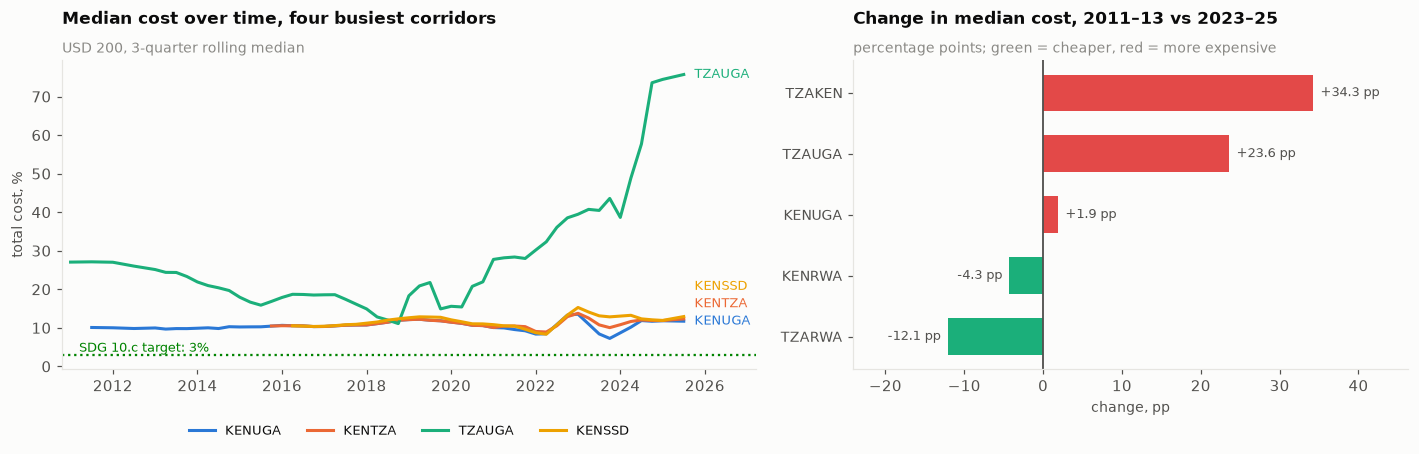

Corridors currently at or below the 3% SDG target: 0 of 8
Corridors where the CHEAPEST offer is below 3%: 8 of 8

>>> TAKEAWAY: NO corridor's median is anywhere near 3%, yet EVERY corridor already
>>> contains at least one sub-3% offer. The SDG target is reachable today with the
>>> providers that already exist — purely by selecting correctly. That is the single
>>> strongest demo claim available from this dataset.


In [14]:
ts = (df.groupby(["corridor", "t"])["cc1 total cost %"].median().reset_index())
big = df.corridor.value_counts().head(4).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3), gridspec_kw={"width_ratios": [1.25, 1]})

ends = []
for name, colr in zip(big, SERIES):
    ser = ts[ts.corridor == name].sort_values("t")
    ser = ser.set_index("t")["cc1 total cost %"].rolling(3, min_periods=1).mean()
    axes[0].plot(ser.index, ser.values, color=colr, label=name)
    ends.append([ser.values[-1], ser.index[-1], name, colr])
# Push overlapping end-labels apart so all four stay legible
ends.sort()
GAP = 4.5
for i in range(1, len(ends)):
    ends[i][0] = max(ends[i][0], ends[i - 1][0] + GAP)
for yv, xv, name, colr in ends:
    axes[0].annotate(name, (xv, yv), textcoords="offset points", xytext=(7, 0),
                     fontsize=8.5, color=colr, va="center")
axes[0].axhline(3, color=C["green"], lw=1.5, ls=":")
axes[0].text(2011.2, 3.8, "SDG 10.c target: 3%", color=C["green"], fontsize=8.5)
axes[0].set_xlim(2010.8, 2027.2)
axes[0].legend(fontsize=8.5, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.14))
style(axes[0], "Median cost over time, four busiest corridors",
      "USD 200, 3-quarter rolling median", xlab="", ylab="total cost, %")

first, last = df[df.year <= 2013], df[df.year >= 2023]
chg = pd.DataFrame({
    "2011-13": first.groupby("corridor")["cc1 total cost %"].median(),
    "2023-25": last.groupby("corridor")["cc1 total cost %"].median(),
}).dropna()
chg["delta"] = chg["2023-25"] - chg["2011-13"]
chg = chg.sort_values("delta")
yy = np.arange(len(chg))
cols = [C["aqua"] if d < 0 else C["red"] for d in chg.delta]
axes[1].barh(yy, chg.delta, color=cols, height=0.6)
axes[1].axvline(0, color=INK2, lw=1.2)
axes[1].set_yticks(yy, chg.index, fontsize=9)
for i, d in enumerate(chg.delta):
    axes[1].text(d + (0.9 if d >= 0 else -0.9), i, f"{d:+.1f} pp", va="center",
                 ha="left" if d >= 0 else "right", fontsize=8.5, color=INK2)
axes[1].set_xlim(chg.delta.min() - 12, chg.delta.max() + 12)
style(axes[1], "Change in median cost, 2011–13 vs 2023–25",
      "percentage points; green = cheaper, red = more expensive",
      xlab="change, pp", xgrid=True)
plt.tight_layout()
plt.show()

now = last.groupby("corridor")["cc1 total cost %"].median()
print(f"Corridors currently at or below the 3% SDG target: "
      f"{(now <= 3).sum()} of {len(now)}")
print(f"Corridors where the CHEAPEST offer is below 3%: "
      f"{(last.groupby('corridor')['cc1 total cost %'].min() <= 3).sum()} of {len(now)}")
print("\n>>> TAKEAWAY: NO corridor's median is anywhere near 3%, yet EVERY corridor already")
print(">>> contains at least one sub-3% offer. The SDG target is reachable today with the")
print(">>> providers that already exist — purely by selecting correctly. That is the single")
print(">>> strongest demo claim available from this dataset.")

### 11b. The market is *diverging*, so the prize is growing

The TZAUGA line above triples after 2019. That is not a change in who was surveyed — the
sample actually became *less* bank-heavy over the period. Tanzanian bank pricing on that
corridor genuinely rose (median 26 % → 53 %) while MTOs on the same corridor stayed near
7 %. Pooling all corridors shows the same divergence.

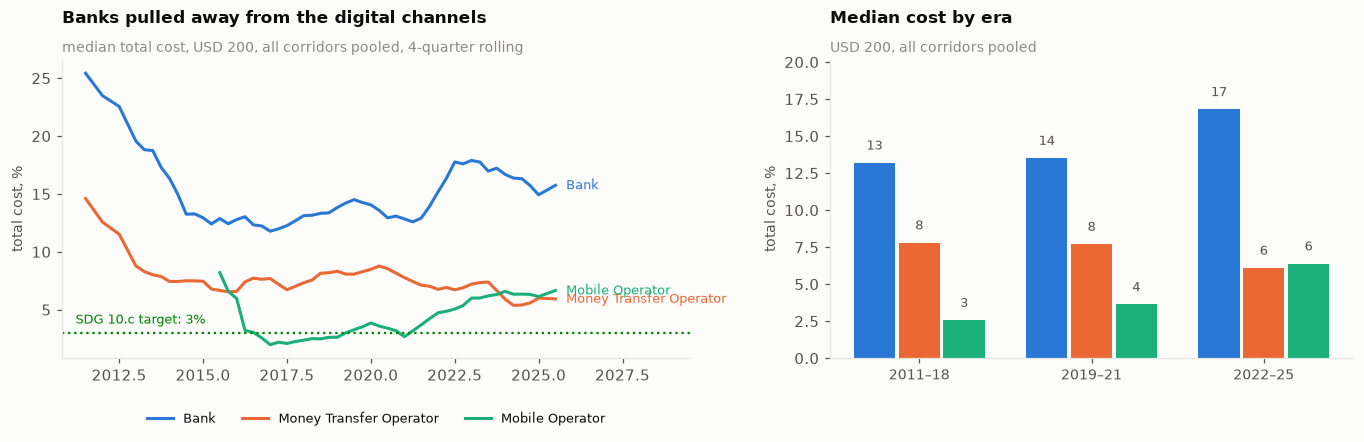

firm_type  Bank  Money Transfer Operator  Mobile Operator
era                                                      
2011–18    13.2                      7.8              2.6
2019–21    13.5                      7.7              3.6
2022–25    16.8                      6.1              6.4

Bank-vs-MTO gap: 5.4 pp in 2011–18 -> 10.7 pp in 2022–25

>>> TAKEAWAY: the bank-vs-MTO spread the optimiser exploits has DOUBLED over 14
>>> years. (Mobile operators rose too, 2.6% -> 6.4%, but from the cheapest base and
>>> still under the banks.) The value of correct provider selection is not a fixed
>>> historical artefact — it is growing, which strengthens the case for routing.


In [15]:
piv = (df.pivot_table(index="t", columns="firm_type", values="cc1 total cost %",
                      aggfunc="median")
         .rolling(4, min_periods=2).mean())
shown = ["Bank", "Money Transfer Operator", "Mobile Operator"]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2), gridspec_kw={"width_ratios": [1.2, 1]})

for name, colr in zip(shown, SAFE3):
    if name in piv:
        ser = piv[name].dropna()
        axes[0].plot(ser.index, ser.values, color=colr, label=name)
        axes[0].annotate(name, (ser.index[-1], ser.values[-1]), textcoords="offset points",
                         xytext=(7, 0), fontsize=8.5, color=colr, va="center")
axes[0].axhline(3, color=C["green"], lw=1.5, ls=":")
axes[0].text(2011.2, 3.8, "SDG 10.c target: 3%", color=C["green"], fontsize=8.5)
axes[0].set_xlim(2010.8, 2029.5)
axes[0].legend(fontsize=8.5, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.14))
style(axes[0], "Banks pulled away from the digital channels",
      "median total cost, USD 200, all corridors pooled, 4-quarter rolling",
      ylab="total cost, %")

era = pd.cut(df.year, [2010, 2018, 2021, 2026], labels=["2011–18", "2019–21", "2022–25"])
tab = (df.assign(era=era)
         .pivot_table(index="era", columns="firm_type", values="cc1 total cost %",
                      aggfunc="median", observed=True)[shown])
x = np.arange(len(tab))
w = 0.26
for i, (name, colr) in enumerate(zip(shown, SAFE3)):
    axes[1].bar(x + (i - 1) * w, tab[name], width=w - 0.02, color=colr, label=name)
    for xi, v in zip(x + (i - 1) * w, tab[name]):
        axes[1].text(xi, v + 0.9, f"{v:.0f}", ha="center", fontsize=8.5, color=INK2)
axes[1].set_xticks(x, tab.index, fontsize=9)
axes[1].set_ylim(0, tab.max().max() * 1.2)
style(axes[1], "Median cost by era", "USD 200, all corridors pooled", ylab="total cost, %")
plt.tight_layout()
plt.show()

gap = (tab["Bank"] - tab["Money Transfer Operator"])
print(tab.round(1).to_string())
print(f"\nBank-vs-MTO gap: {gap.iloc[0]:.1f} pp in {tab.index[0]} -> "
      f"{gap.iloc[-1]:.1f} pp in {tab.index[-1]}")
print("\n>>> TAKEAWAY: the bank-vs-MTO spread the optimiser exploits has DOUBLED over 14")
print(">>> years. (Mobile operators rose too, 2.6% -> 6.4%, but from the cheapest base and")
print(">>> still under the banks.) The value of correct provider selection is not a fixed")
print(">>> historical artefact — it is growing, which strengthens the case for routing.")

## 12. Insight 8 — cost is strongly non-linear in amount, so weights must be per-amount

RPW prices the same offer at USD 200 and USD 500. Comparing them exposes the flat-fee
structure that makes small transfers so expensive.

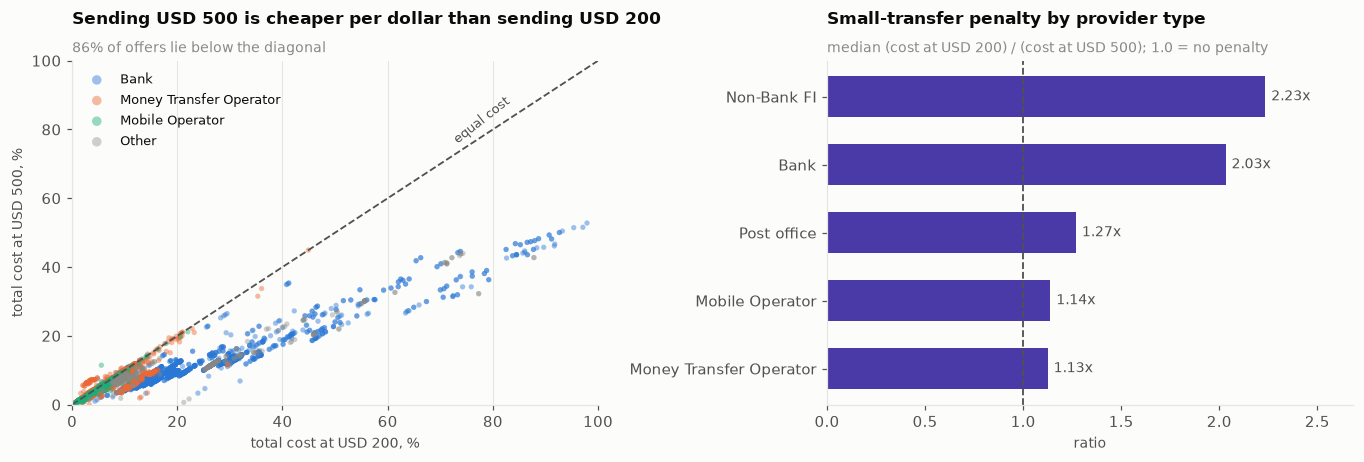

>>> TAKEAWAY: the objective coefficients are amount-dependent, so the model must be
>>> solved per send-amount — the optimal provider at USD 200 is often not the optimal
>>> provider at USD 500. This is also a second decision variable worth exposing:
>>> splitting or consolidating transfers changes which firm wins.


In [16]:
d2 = df.dropna(subset=["cc1 total cost %", "cc2 total cost %"])
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))

for name, col in zip(top3, SAFE3):
    s = d2[d2.firm_type == name]
    axes[0].scatter(s["cc1 total cost %"], s["cc2 total cost %"], s=12, alpha=0.45,
                    color=col, edgecolor="none", label=name)
s = d2[~d2.firm_type.isin(top3)]
axes[0].scatter(s["cc1 total cost %"], s["cc2 total cost %"], s=12, alpha=0.4, color=INK3,
                edgecolor="none", label="Other")
lim = [0, 100]
axes[0].plot(lim, lim, color=INK2, lw=1.2, ls="--")
axes[0].text(72, 76, "equal cost", fontsize=8.5, color=INK2, rotation=38)
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 100)
axes[0].legend(fontsize=8.5, loc="upper left", markerscale=1.8)
style(axes[0], "Sending USD 500 is cheaper per dollar than sending USD 200",
      f"{(d2['cc2 total cost %'] < d2['cc1 total cost %']).mean():.0%} of offers lie below the diagonal",
      xlab="total cost at USD 200, %", ylab="total cost at USD 500, %")
axes[0].grid(axis="x")

ratio = (d2.groupby("firm_type")
         .apply(lambda g: (g["cc1 total cost %"] / g["cc2 total cost %"].replace(0, np.nan)).median())
         .sort_values())
axes[1].barh(ratio.index, ratio.values, color=C["violet"], height=0.6)
axes[1].axvline(1, color=INK2, lw=1.2, ls="--")
for k, v in ratio.items():
    axes[1].text(v + 0.03, k, f"{v:.2f}x", va="center", fontsize=9, color=INK2)
axes[1].set_xlim(0, ratio.max() * 1.2)
style(axes[1], "Small-transfer penalty by provider type",
      "median (cost at USD 200) / (cost at USD 500); 1.0 = no penalty",
      xlab="ratio", xgrid=True)
plt.tight_layout()
plt.show()

print(">>> TAKEAWAY: the objective coefficients are amount-dependent, so the model must be")
print(">>> solved per send-amount — the optimal provider at USD 200 is often not the optimal")
print(">>> provider at USD 500. This is also a second decision variable worth exposing:")
print(">>> splitting or consolidating transfers changes which firm wins.")

## 13. What the EDA implies for the mathematical formulation

### Decision variables
For a corridor $(a,b)$ in quarter $q$, let $x_k \in \{0,1\}$ select offer $k$ from the
feasible set $\mathcal{F}_{ab,q}$ ($|\mathcal{F}| \le 27$, mean 16). One-hot constraint:
$\sum_k x_k = 1$. For the routing extension, $x_{e,k}$ selects offer $k$ on arc $e$, with
flow conservation over the 5-node graph.

### Objective vector
Each offer carries $(f_k,\ s_k,\ \tau_k)$ = fee %, FX margin %, settlement hours.
They live on incomparable scales (fee 0–76, FX −13–29, hours 0.5–96), so **normalise
within the corridor-quarter** before weighting — otherwise the hours term silently
dominates:

$$\min_{x} \; \sum_k x_k \Big( w_f \tilde f_k + w_s \tilde s_k + w_\tau \tilde\tau_k \Big),
\qquad \tilde z_k = \frac{z_k - \min_j z_j}{\max_j z_j - \min_j z_j}$$

### Three things the data changes about the naive formulation

1. **Do not add fee and total cost.** `total cost % = fee % + fx margin` — using both
   double-counts. Use the *(fee, FX)* pair, or total cost alone, never a mix.
2. **Speed is a constraint, not a third competing objective** (§6): cost and time are
   positively correlated, so $w_\tau$ trades along a *dominated* direction. Prefer
   $\tau_k \le T_{\max}$ as a penalty term $\lambda \sum_k x_k \max(0, \tau_k - T_{\max})$.
3. **Keep negative FX margins** (§2d): 120 offers beat the interbank mid, and they sit on
   the Pareto front.

### QUBO
$$H = \underbrace{\sum_k c_k x_k}_{\text{weighted cost}}
    + \underbrace{\lambda_1\Big(\sum_k x_k - 1\Big)^2}_{\text{one-hot}}
    + \underbrace{\lambda_2 \sum_k x_k\,\max(0, \tau_k - T_{\max})}_{\text{deadline}}$$
with $c_k = w_f\tilde f_k + w_s\tilde s_k$. Set $\lambda_1 > \max_k c_k$ so the one-hot
constraint cannot be bought.

### Be honest about where the hardness is

Single-corridor provider selection under a one-hot constraint is **linear**: the optimum is
found by evaluating $|\mathcal{F}| \le 27$ candidates. It is a correctness benchmark, not a
hard instance — which is exactly what makes it the right first milestone, because every
QAOA run has an exact ground truth to be scored against.

The combinatorics only appear in the extensions, all of which this data supports:

* **multi-hop routing** (§10) — select an offer *per arc* along a path, with flow
  conservation; costs compound multiplicatively, so the arc weights are $\log(1-c_e)$
  and the objective stops being separable;
* **splitting a transfer** across providers, where the USD 200 / USD 500 non-linearity
  of §12 makes the cost function concave in amount;
* **a portfolio over a quarter** — many transfers, provider capacity or exposure caps,
  which couples the otherwise independent one-hot blocks and is where a QUBO earns its keep.

### Expected outputs this EDA supports
* a **weight-sweep**: as $(w_f, w_s)$ rotates, which firm wins? (produces the Pareto front
  of §9 as a decision map)
* a **savings figure**: optimiser vs. median offer, ~20 pp of principal (§7)
* a **routing result**: 4 country pairs made reachable and 2 made cheaper, by 2-hop
  composition through Kenya (§10)

In [17]:
# ---- Export the modelling table -----------------------------------------------
OUT = Path("../Data/rpw_east_africa_clean.csv")
keep = ["id", "period", "year", "t", "corridor", "src", "dst", "firm", "firm_type",
        "access point", "speed actual", "hours", "transparent",
        "receiving network coverage", "pickup method", "payment instrument",
        "cc1 fee %", "cc1 fx margin", "cc1 total cost %",
        "cc2 fee %", "cc2 fx margin", "cc2 total cost %"]
model_df = df[keep].rename(columns={
    "cc1 fee %": "fee_pct_200", "cc1 fx margin": "fx_margin_200", "cc1 total cost %": "total_cost_200",
    "cc2 fee %": "fee_pct_500", "cc2 fx margin": "fx_margin_500", "cc2 total cost %": "total_cost_500",
    "speed actual": "speed_band", "hours": "speed_hours", "access point": "access_point",
    "receiving network coverage": "network_coverage", "pickup method": "pickup_method",
    "payment instrument": "payment_instrument"})
model_df.to_csv(OUT, index=False)
print(f"wrote {OUT}  ({len(model_df):,} rows x {model_df.shape[1]} cols)")

# A ready-to-solve instance: one corridor-quarter's feasible set
inst = (model_df[(model_df.corridor == "KENUGA") & (model_df.period == "2025_3Q")]
        [["firm", "firm_type", "fee_pct_200", "fx_margin_200", "speed_hours", "total_cost_200"]]
        .sort_values("total_cost_200").reset_index(drop=True))
print(f"\nExample instance — KEN->UGA, 2025 Q3, {len(inst)} candidate offers "
      f"({len(inst)} binary variables):")
inst.round(2)

wrote ../Data/rpw_east_africa_clean.csv  (4,504 rows x 22 cols)

Example instance — KEN->UGA, 2025 Q3, 27 candidate offers (27 binary variables):


,firm,firm_type,fee_pct_200,fx_margin_200,speed_hours,total_cost_200
0,Dahabshiil,Money Transfer Operator,2.30,0.55,12.0,2.85
1,MoneyGram,Money Transfer Operator,1.94,2.51,0.5,4.45
2,MoneyGram,Money Transfer Operator,1.94,2.51,0.5,4.45
3,EcoBank Rapid Transfer,Bank,2.88,1.81,0.5,4.69
4,EcoBank Rapid Transfer,Bank,2.88,1.81,0.5,4.69
5,EcoBank Rapid Transfer,Bank,2.88,1.81,0.5,4.69
6,EcoBank Rapid Transfer,Bank,2.88,1.85,0.5,4.73
7,Western Union,Money Transfer Operator,1.15,4.65,0.5,5.80
8,M-Pesa,Mobile Operator,1.94,4.23,0.5,6.17
9,M-Pesa,Mobile Operator,1.94,4.23,0.5,6.17


## 14. Summary of findings

| # | Finding | Consequence for the model |
|---|---|---|
| 1 | FX margin is **21 %** of the median bill but correlates only **r = 0.40** with the fee | Cost is genuinely 2-dimensional; fee-only routing is blind to the axis providers differ on most |
| 2 | Faster channels are **cheaper**, not dearer (Spearman ρ > 0 between hours and cost) | Speed is a **constraint**, not a competing objective — the brief's premise is wrong here |
| 3 | Cheapest vs median offer differs by **~20 pp** of principal | The prize is far larger than the 15–30 % in the brief; selection alone captures it |
| 4 | The market is **bimodal**: bank wires ~30–90 %, digital channels ~2–7 % | `firm_type` is a strong prior but mistyped on some rows — use measured coefficients |
| 5 | Only **29 %** of offers are Pareto-optimal; 16 offers per corridor-quarter on average | Prune classically, then a **≤27-variable** one-hot QUBO with exact ground truth |
| 6 | Only **8 of 20** country pairs have a priced corridor; Uganda and South Sudan are sinks | 2-hop composition through Kenya unlocks **4** pairs and beats direct on **2** — the graph problem |
| 7 | No corridor's **median** is near the 3 % SDG target, yet **all 8** contain a sub-3 % offer | The headline demo: optimisation reaches the SDG target with today's providers |
| 8 | USD 200 costs **1.67×** more per dollar than USD 500 (median offer) | Coefficients are amount-dependent; solve per send-amount |

| 9 | The bank-vs-MTO cost gap **doubled**, 5.4 pp (2011–18) → 10.7 pp (2022–25) | The prize is growing, not closing — the case for routing strengthens over time |

### Known limitations
* RPW is an **advertised-price survey**, not settled transactions — no volumes, no liquidity,
  no evidence a corridor could absorb rerouted flow.
* `speed actual` is an **ordinal band**, not a measured time; the hour values are midpoints
  chosen for ordering, and any absolute-time claim inherits that assumption.
* Coverage is uneven: TZAKEN/TZAUGA medians are inflated by a bank-heavy sample, so
  corridor-level medians are **not** population averages of what senders actually pay.
* Composed 2-hop costs assume the intermediate leg can be re-originated at retail prices —
  an upper bound on the achievable saving, not a quote.